# Parte B — Análise e descrição das variáveis

Este notebook foi estruturado para a **parte descritiva** do trabalho, com foco no tema:

**Diferenças estatísticas entre gêneros**

Variáveis analisadas:
- **Gênero**
- **Altura**
- **Peso**
- **Opinião sobre degradação ambiental**
- **Opinião sobre regulação de fake news**
- **Número de redes sociais**

---

## Objetivos desta parte
1. Identificar o tipo de cada variável.
2. Produzir estatísticas descritivas adequadas.
3. Visualizar os dados com tabelas e gráficos.
4. Organizar resultados que poderão ser reaproveitados no **relatório final**.

## Inicialização

Nesta etapa:
- importamos as bibliotecas;
- carregamos a planilha;
- selecionamos apenas as variáveis de interesse;
- conferimos os nomes exatos das colunas.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

In [ ]:
# Caminho esperado:
# projeto/
# ├── datasets/
# │   └── 2026ABC121dados.xlsx
# └── notebooks/
#     └── experiments 
#         └──  este_notebook.ipynb

PATH = "../../datasets/2026ABC121dados.xlsx"

df_bruto = pd.read_excel(PATH)
print("Dimensão da base:", df_bruto.shape)
print("\nColunas disponíveis:")
print(df_bruto.columns.tolist())

Dimensão da base: (195, 19)

Colunas disponíveis:
['Ident', 'Ano', 'Turma', 'Idade', 'Altura', 'Peso', 'Irmãos', 'Gênero', 'Uso_dados_pessoais', 'Big_tech_ética', 'Num_redes_sociais', 'Regulação_fake_news', 'Mudanças_climáticas', 'Degradação_meio_ambiente', 'Tempo_banho', 'Tempo_transporte', 'Alimentação', 'Tempo_sono', 'Tempo_tela']


In [5]:
variaveis = [
    "Gênero",
    "Altura",
    "Peso",
    "Degradação_meio_ambiente",
    "Regulação_fake_news",
    "Num_redes_sociais",
]

df = df_bruto[variaveis].copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gênero                    195 non-null    object 
 1   Altura                    195 non-null    int64  
 2   Peso                      195 non-null    float64
 3   Degradação_meio_ambiente  195 non-null    object 
 4   Regulação_fake_news       195 non-null    object 
 5   Num_redes_sociais         195 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 9.3+ KB


## Classificação das variáveis

A tabela abaixo registra a natureza de cada variável, o que será útil no relatório.

In [6]:
classificacao = pd.DataFrame({
    "Variável": [
        "Gênero",
        "Altura",
        "Peso",
        "Degradação_meio_ambiente",
        "Regulação_fake_news",
        "Num_redes_sociais",
    ],
    "Tipo": [
        "Qualitativa",
        "Quantitativa",
        "Quantitativa",
        "Qualitativa",
        "Qualitativa",
        "Quantitativa",
    ],
    "Subtipo": [
        "Nominal",
        "Contínua",
        "Contínua",
        "Ordinal",
        "Nominal",
        "Discreta",
    ],
    "Observação": [
        "Categorias de identidade de gênero.",
        "Medida numérica de estatura.",
        "Medida numérica de massa corporal.",
        "Escala ordenável de concordância.",
        "Resposta categórica sem ordem natural forte.",
        "Contagem de redes sociais utilizadas.",
    ],
})

classificacao

,Variável,Tipo,Subtipo,Observação
0,Gênero,Qualitativa,Nominal,Categorias de identidade de gênero.
1,Altura,Quantitativa,Contínua,Medida numérica de estatura.
2,Peso,Quantitativa,Contínua,Medida numérica de massa corporal.
3,Degradação_meio_ambiente,Qualitativa,Ordinal,Escala ordenável de concordância.
4,Regulação_fake_news,Qualitativa,Nominal,Resposta categórica sem ordem natural forte.
5,Num_redes_sociais,Quantitativa,Discreta,Contagem de redes sociais utilizadas.


## Tratamento inicial e checagem de faltantes

In [7]:
df.isna().sum().to_frame("Valores ausentes")

,Valores ausentes
Gênero,0
Altura,0
Peso,0
Degradação_meio_ambiente,0
Regulação_fake_news,0
Num_redes_sociais,0


## Visão geral dos dados

Aqui obtemos:
- estatísticas gerais para as variáveis quantitativas;
- uma primeira inspeção das variáveis qualitativas.

In [8]:
df.describe(include="all")

,Gênero,Altura,Peso,Degradação_meio_ambiente,Regulação_fake_news,Num_redes_sociais
count,195,195.000000,195.000000,195,195,195.000000
unique,4,NaN,NaN,5,3,NaN
top,Masculino,NaN,NaN,Concordo parcialmente,Sim,NaN
freq,154,NaN,NaN,83,168,NaN
mean,NaN,173.610256,72.267692,NaN,NaN,4.015385
std,NaN,8.417085,15.456992,NaN,NaN,2.601500
min,NaN,150.000000,37.000000,NaN,NaN,0.000000
25%,NaN,169.500000,60.000000,NaN,NaN,2.000000
50%,NaN,174.000000,70.000000,NaN,NaN,3.000000
75%,NaN,180.000000,82.000000,NaN,NaN,5.000000


# 1. Variável: Gênero

**Classificação:** qualitativa nominal.

Para essa variável, o mais importante é apresentar:
- frequências absolutas;
- frequências relativas;
- gráfico de barras.

In [9]:
freq_genero = df["Gênero"].value_counts(dropna=False).rename("Frequência")
prop_genero = df["Gênero"].value_counts(normalize=True, dropna=False).mul(100).round(2).rename("%")

tabela_genero = pd.concat([freq_genero, prop_genero], axis=1)
tabela_genero

,Frequência,%
Gênero,,
Masculino,154,78.97
Feminino,31,15.90
Outro,5,2.56
Prefiro não dizer,5,2.56


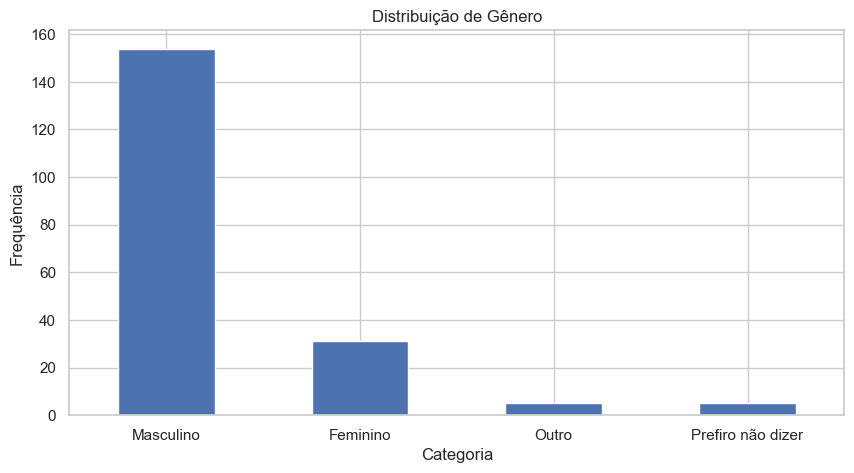

In [10]:
ax = tabela_genero["Frequência"].plot(kind="bar")
ax.set_title("Distribuição de Gênero")
ax.set_xlabel("Categoria")
ax.set_ylabel("Frequência")
plt.xticks(rotation=0)
plt.show()

### Comentário para o relatório
Use este trecho como guia de redação:

> A variável **Gênero** é qualitativa nominal, pois representa categorias sem ordem natural.  
> A amostra apresenta predominância de participantes do gênero **Masculino**, correspondendo a **78.97%** do total.


# 2. Variável: Altura

**Classificação:** quantitativa contínua.

Para variáveis quantitativas contínuas, é recomendável apresentar:
- média, mediana e desvio padrão;
- quartis, mínimo e máximo;
- histograma;
- boxplot;
- resumo por gênero.

In [11]:
altura_desc = df["Altura"].describe()
altura_desc

count    195.000000
mean     173.610256
std        8.417085
min      150.000000
25%      169.500000
50%      174.000000
75%      180.000000
max      196.000000
Name: Altura, dtype: float64

In [12]:
altura_medidas = pd.Series({
    "média": df["Altura"].mean(),
    "mediana": df["Altura"].median(),
    "desvio padrão": df["Altura"].std(),
    "variância": df["Altura"].var(),
    "amplitude": df["Altura"].max() - df["Altura"].min(),
    "coeficiente de variação (%)": (df["Altura"].std() / df["Altura"].mean()) * 100,
}).round(2)

altura_medidas

média                          173.61
mediana                        174.00
desvio padrão                    8.42
variância                       70.85
amplitude                       46.00
coeficiente de variação (%)      4.85
dtype: float64

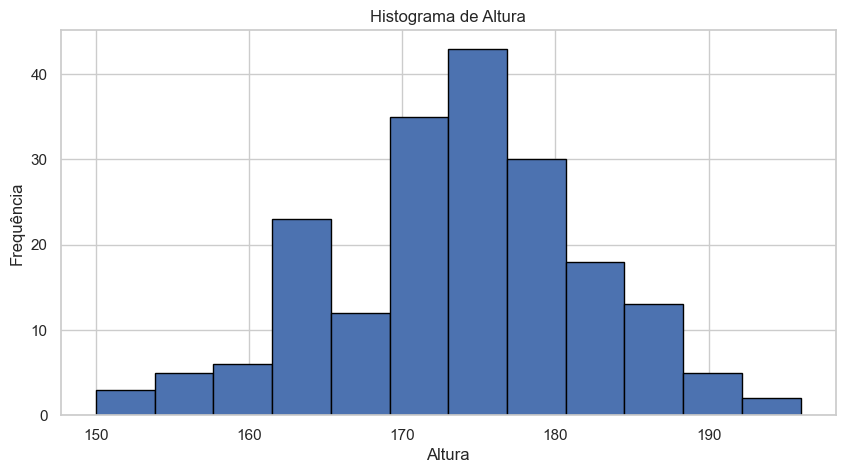

In [13]:
fig, ax = plt.subplots()
ax.hist(df["Altura"], bins=12, edgecolor="black")
ax.set_title("Histograma de Altura")
ax.set_xlabel("Altura")
ax.set_ylabel("Frequência")
plt.show()

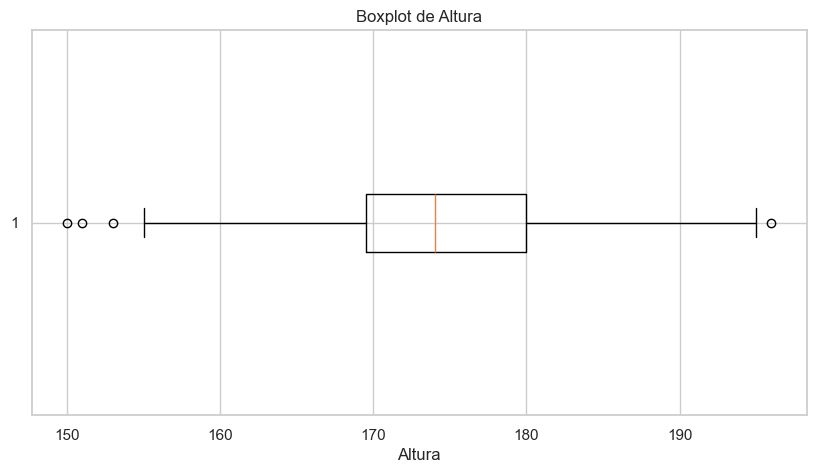

In [14]:
fig, ax = plt.subplots()
ax.boxplot(df["Altura"].dropna(), vert=False)
ax.set_title("Boxplot de Altura")
ax.set_xlabel("Altura")
plt.show()

In [15]:
df.groupby("Gênero")["Altura"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Gênero,,,,,,,,
Feminino,31.0,164.39,8.09,150.0,160.0,164.0,169.0,185.0
Masculino,154.0,175.91,6.92,160.0,171.0,175.0,180.0,196.0
Outro,5.0,166.40,10.21,157.0,158.0,165.0,170.0,182.0
Prefiro não dizer,5.0,167.20,5.26,162.0,164.0,165.0,170.0,175.0


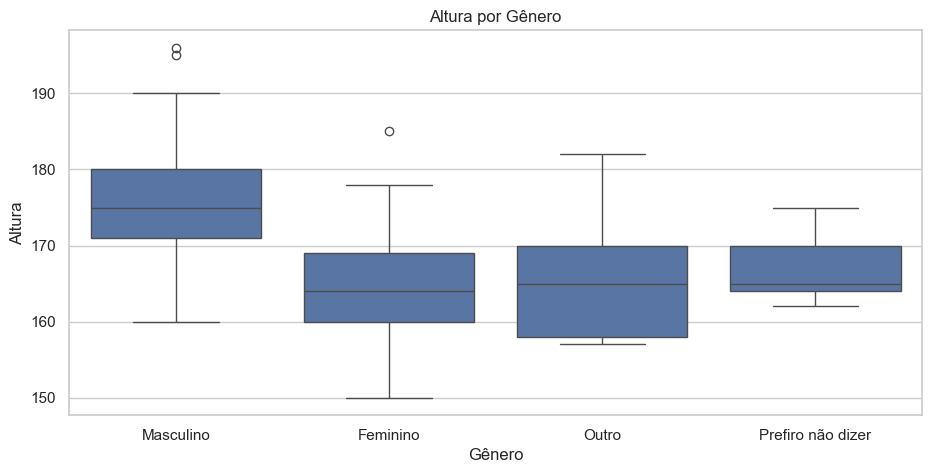

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x="Gênero", y="Altura", ax=ax)
ax.set_title("Altura por Gênero")
ax.set_xlabel("Gênero")
ax.set_ylabel("Altura")
plt.xticks(rotation=0)
plt.show()

### Comentário para o relatório
Sugestão de redação:

> A variável **Altura** é quantitativa contínua.  
> Na amostra total, a altura média foi de **173.61**, com mediana igual a **174.00** e desvio padrão de **8.42**.  
> O boxplot por gênero permite observar **valores centrais mais altos no grupo Masculino do que no Feminino, enquanto os grupos "Outro" e "Prefiro não dizer" têm poucos casos e, por isso, menor estabilidade para comparação**.


# 3. Variável: Peso

**Classificação:** quantitativa contínua.

In [17]:
peso_desc = df["Peso"].describe()
peso_desc

count    195.000000
mean      72.267692
std       15.456992
min       37.000000
25%       60.000000
50%       70.000000
75%       82.000000
max      120.000000
Name: Peso, dtype: float64

In [18]:
peso_medidas = pd.Series({
    "média": df["Peso"].mean(),
    "mediana": df["Peso"].median(),
    "desvio padrão": df["Peso"].std(),
    "variância": df["Peso"].var(),
    "amplitude": df["Peso"].max() - df["Peso"].min(),
    "coeficiente de variação (%)": (df["Peso"].std() / df["Peso"].mean()) * 100,
}).round(2)

peso_medidas

média                           72.27
mediana                         70.00
desvio padrão                   15.46
variância                      238.92
amplitude                       83.00
coeficiente de variação (%)     21.39
dtype: float64

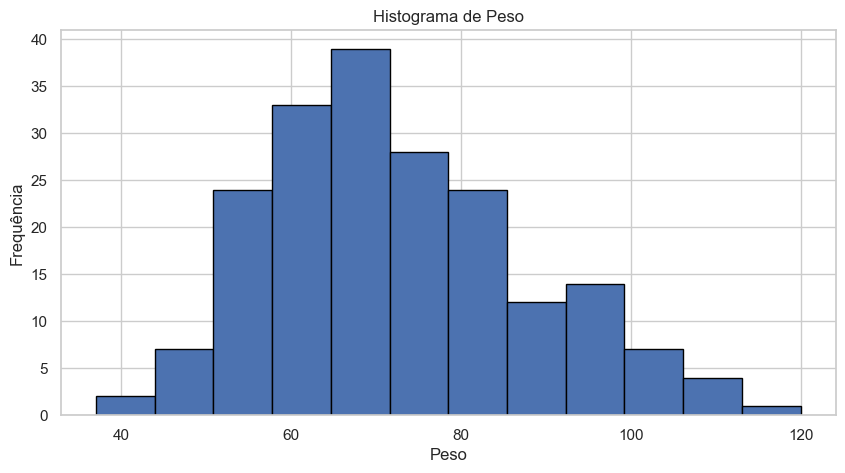

In [19]:
fig, ax = plt.subplots()
ax.hist(df["Peso"], bins=12, edgecolor="black")
ax.set_title("Histograma de Peso")
ax.set_xlabel("Peso")
ax.set_ylabel("Frequência")
plt.show()

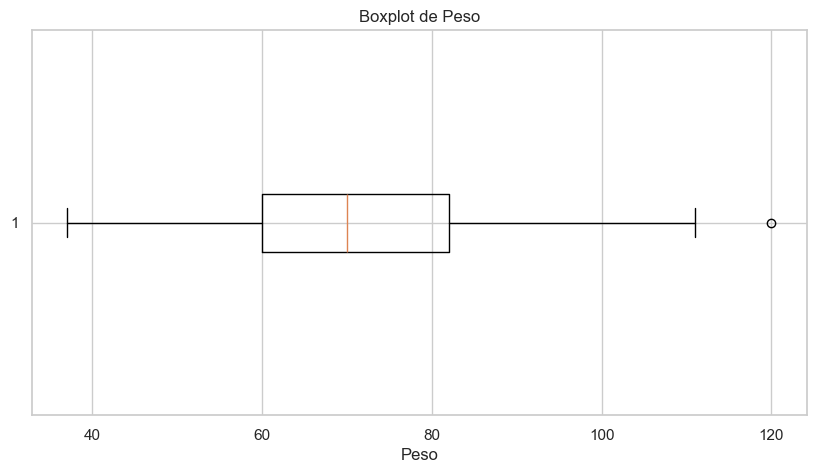

In [20]:
fig, ax = plt.subplots()
ax.boxplot(df["Peso"].dropna(), vert=False)
ax.set_title("Boxplot de Peso")
ax.set_xlabel("Peso")
plt.show()

In [21]:
df.groupby("Gênero")["Peso"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Gênero,,,,,,,,
Feminino,31.0,61.82,16.02,37.0,55.50,59.00,65.5,120.0
Masculino,154.0,74.68,14.49,44.0,64.25,72.15,83.0,111.0
Outro,5.0,65.00,19.80,50.0,50.00,52.00,83.0,90.0
Prefiro não dizer,5.0,70.00,9.92,56.0,64.00,74.00,75.0,81.0


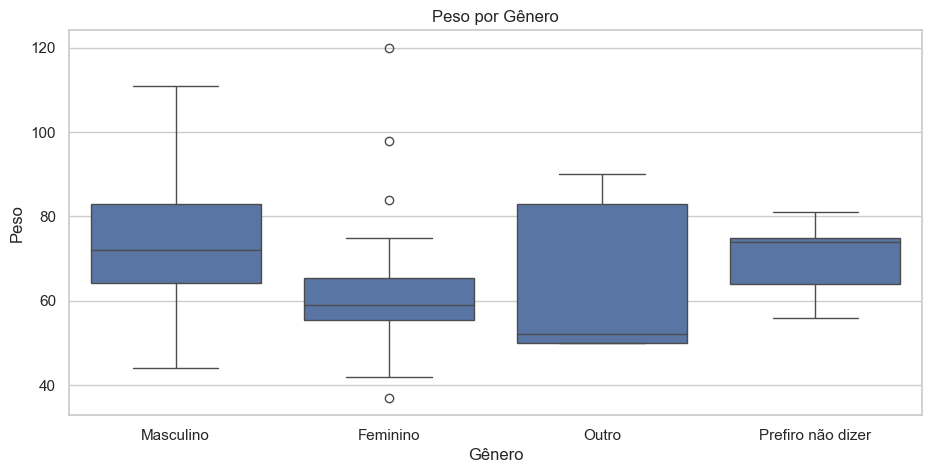

In [22]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x="Gênero", y="Peso", ax=ax)
ax.set_title("Peso por Gênero")
ax.set_xlabel("Gênero")
ax.set_ylabel("Peso")
plt.xticks(rotation=0)
plt.show()

### Comentário para o relatório
Sugestão de redação:

> A variável **Peso** é quantitativa contínua.  
> O peso médio observado foi de **72.27**, com mediana de **70.00**.  
> A comparação por gênero sugere **valores centrais mais altos no grupo Masculino do que no Feminino, embora os grupos "Outro" e "Prefiro não dizer" tenham tamanho amostral muito pequeno**.


# 4. Variável: Opinião sobre degradação ambiental

**Coluna usada na base:** `Degradação_meio_ambiente`  
**Classificação:** qualitativa ordinal.

Como existe ordem natural entre os níveis de concordância, faz sentido:
- mostrar frequências;
- organizar a ordem das categorias;
- comparar distribuições por gênero.

In [23]:
ordem_degradacao = [
    "Discordo totalmente",
    "Discordo parcialmente",
    "Neutro/Indiferente",
    "Concordo parcialmente",
    "Concordo totalmente",
]

degradacao_freq = (
    df["Degradação_meio_ambiente"]
    .value_counts()
    .reindex(ordem_degradacao)
    .fillna(0)
    .astype(int)
    .rename("Frequência")
)

degradacao_perc = (
    df["Degradação_meio_ambiente"]
    .value_counts(normalize=True)
    .reindex(ordem_degradacao)
    .mul(100)
    .round(2)
    .rename("%")
)

pd.concat([degradacao_freq, degradacao_perc], axis=1)

,Frequência,%
Degradação_meio_ambiente,,
Discordo totalmente,19,9.74
Discordo parcialmente,53,27.18
Neutro/Indiferente,21,10.77
Concordo parcialmente,83,42.56
Concordo totalmente,19,9.74


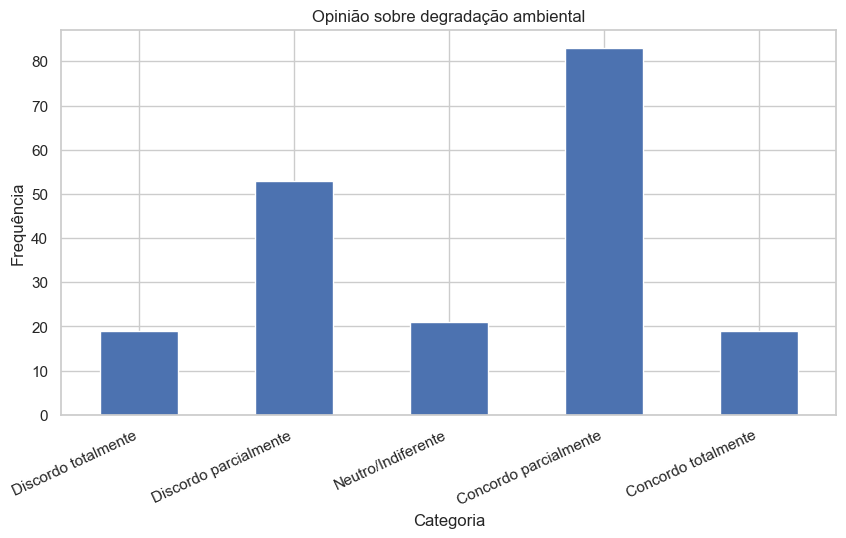

In [24]:
ax = degradacao_freq.plot(kind="bar")
ax.set_title("Opinião sobre degradação ambiental")
ax.set_xlabel("Categoria")
ax.set_ylabel("Frequência")
plt.xticks(rotation=25, ha="right")
plt.show()

In [25]:
tabela_degradacao_genero = pd.crosstab(
    df["Gênero"],
    df["Degradação_meio_ambiente"],
    normalize="index"
).reindex(columns=ordem_degradacao) * 100

tabela_degradacao_genero.round(2)

Degradação_meio_ambiente,Discordo totalmente,Discordo parcialmente,Neutro/Indiferente,Concordo parcialmente,Concordo totalmente
Gênero,,,,,
Feminino,3.23,19.35,3.23,67.74,6.45
Masculino,11.69,27.92,12.99,37.01,10.39
Outro,0.00,40.00,0.00,40.00,20.00
Prefiro não dizer,0.00,40.00,0.00,60.00,0.00


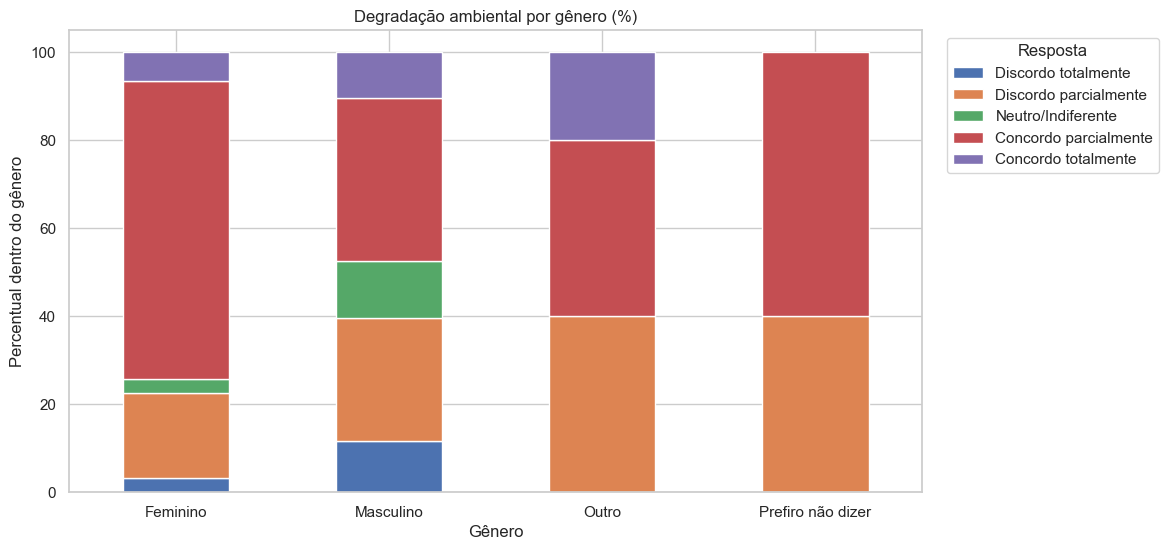

In [26]:
ax = tabela_degradacao_genero.plot(kind="bar", stacked=True, figsize=(11, 6))
ax.set_title("Degradação ambiental por gênero (%)")
ax.set_xlabel("Gênero")
ax.set_ylabel("Percentual dentro do gênero")
plt.xticks(rotation=0)
plt.legend(title="Resposta", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

### Comentário para o relatório
Sugestão de redação:

> A variável **Opinião sobre degradação ambiental** é qualitativa ordinal, pois as categorias representam níveis ordenáveis de concordância.  
> Observou-se maior concentração de respostas em **"Concordo parcialmente"**, com **42.56%** da amostra.  
> Na comparação entre gêneros, nota-se **predomínio dessa resposta em todos os grupos, especialmente no Feminino, enquanto o grupo Masculino apresenta distribuição mais dispersa entre concordância, discordância e neutralidade**.


# 5. Variável: Opinião sobre regulação de fake news

**Coluna usada na base:** `Regulação_fake_news`  
**Classificação:** qualitativa nominal.

In [27]:
fake_freq = df["Regulação_fake_news"].value_counts(dropna=False).rename("Frequência")
fake_perc = df["Regulação_fake_news"].value_counts(normalize=True, dropna=False).mul(100).round(2).rename("%")

pd.concat([fake_freq, fake_perc], axis=1)

,Frequência,%
Regulação_fake_news,,
Sim,168,86.15
Não,14,7.18
Não sei / não tenho opinião,13,6.67


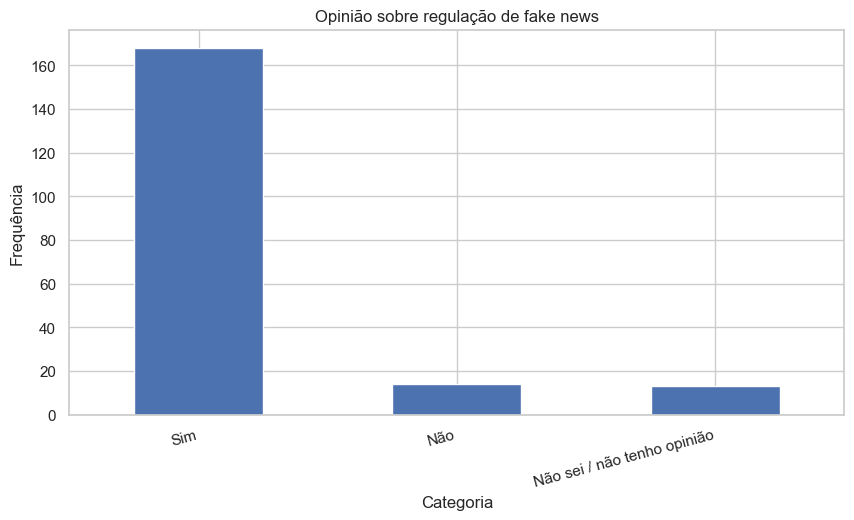

In [28]:
ax = df["Regulação_fake_news"].value_counts().plot(kind="bar")
ax.set_title("Opinião sobre regulação de fake news")
ax.set_xlabel("Categoria")
ax.set_ylabel("Frequência")
plt.xticks(rotation=15, ha="right")
plt.show()

In [29]:
tabela_fake_genero = pd.crosstab(
    df["Gênero"],
    df["Regulação_fake_news"],
    normalize="index"
) * 100

tabela_fake_genero.round(2)

Regulação_fake_news,Não,Não sei / não tenho opinião,Sim
Gênero,,,
Feminino,0.00,3.23,96.77
Masculino,9.09,7.79,83.12
Outro,0.00,0.00,100.00
Prefiro não dizer,0.00,0.00,100.00


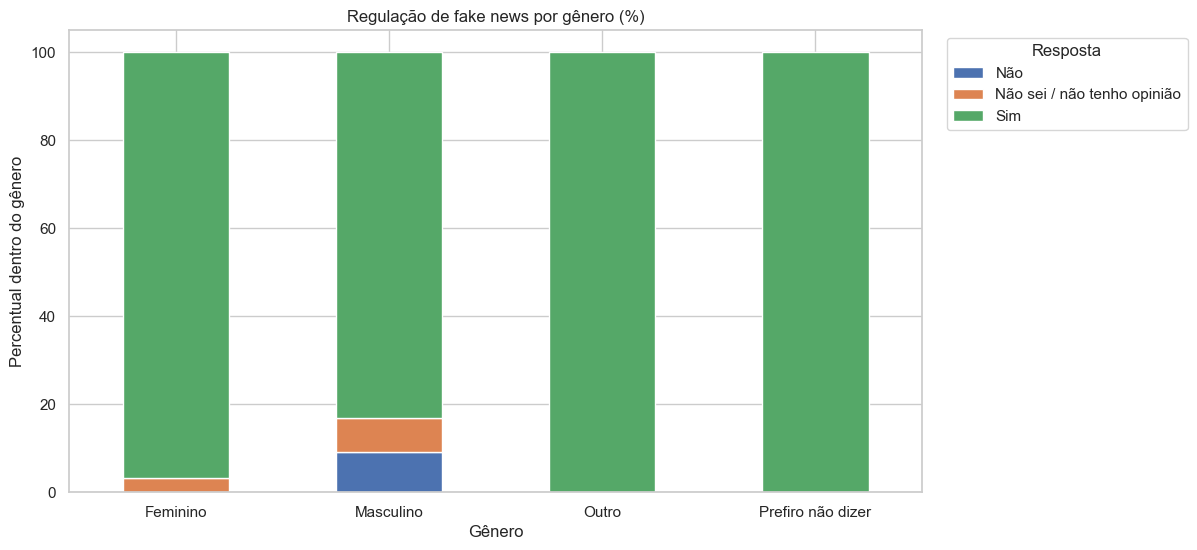

In [30]:
ax = tabela_fake_genero.plot(kind="bar", stacked=True, figsize=(11, 6))
ax.set_title("Regulação de fake news por gênero (%)")
ax.set_xlabel("Gênero")
ax.set_ylabel("Percentual dentro do gênero")
plt.xticks(rotation=0)
plt.legend(title="Resposta", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

### Comentário para o relatório
Sugestão de redação:

> A variável **Opinião sobre regulação de fake news** é qualitativa nominal.  
> A categoria mais frequente foi **"Sim"**, representando **86.15%** da amostra.  
> Na estratificação por gênero, percebe-se **amplo predomínio da resposta "Sim" em todos os grupos, com apoio quase unânime entre Feminino, Outro e Prefiro não dizer, e maioria também no Masculino**.


# 6. Variável: Número de redes sociais

**Coluna usada na base:** `Num_redes_sociais`  
**Classificação:** quantitativa discreta.

In [31]:
num_redes_desc = df["Num_redes_sociais"].describe()
num_redes_desc

count    195.000000
mean       4.015385
std        2.601500
min        0.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       16.000000
Name: Num_redes_sociais, dtype: float64

In [32]:
num_redes_medidas = pd.Series({
    "média": df["Num_redes_sociais"].mean(),
    "mediana": df["Num_redes_sociais"].median(),
    "desvio padrão": df["Num_redes_sociais"].std(),
    "variância": df["Num_redes_sociais"].var(),
    "amplitude": df["Num_redes_sociais"].max() - df["Num_redes_sociais"].min(),
    "coeficiente de variação (%)": (df["Num_redes_sociais"].std() / df["Num_redes_sociais"].mean()) * 100,
}).round(2)

num_redes_medidas

média                           4.02
mediana                         3.00
desvio padrão                   2.60
variância                       6.77
amplitude                      16.00
coeficiente de variação (%)    64.79
dtype: float64

In [33]:
freq_redes = df["Num_redes_sociais"].value_counts().sort_index()
freq_redes.to_frame("Frequência")

,Frequência
Num_redes_sociais,
0,3
1,17
2,39
3,40
4,30
5,32
6,9
7,5
8,7


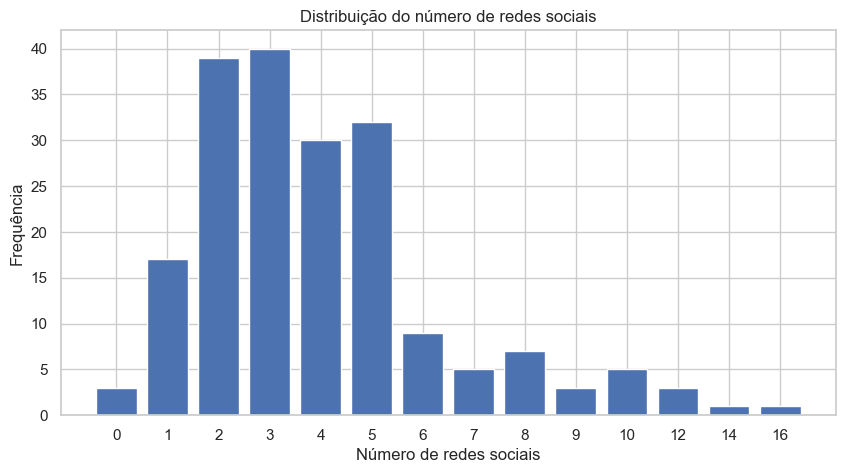

In [34]:
fig, ax = plt.subplots()
ax.bar(freq_redes.index.astype(str), freq_redes.values)
ax.set_title("Distribuição do número de redes sociais")
ax.set_xlabel("Número de redes sociais")
ax.set_ylabel("Frequência")
plt.show()

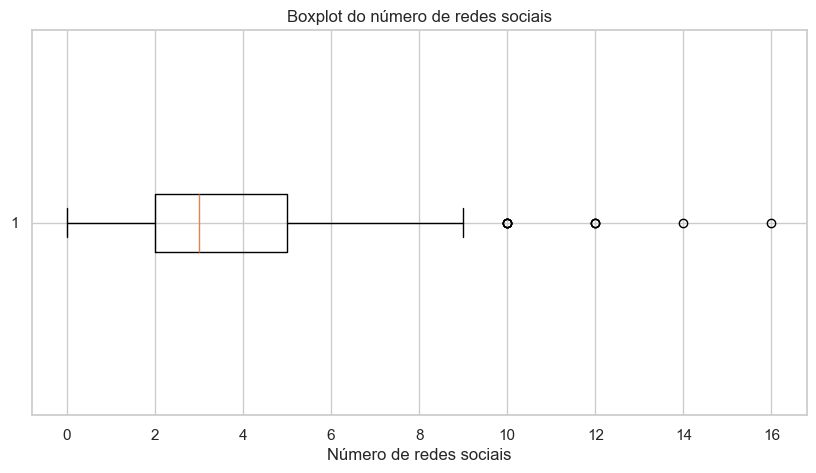

In [35]:
fig, ax = plt.subplots()
ax.boxplot(df["Num_redes_sociais"].dropna(), vert=False)
ax.set_title("Boxplot do número de redes sociais")
ax.set_xlabel("Número de redes sociais")
plt.show()

In [36]:
df.groupby("Gênero")["Num_redes_sociais"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Gênero,,,,,,,,
Feminino,31.0,4.23,2.31,1.0,2.0,4.0,5.0,10.0
Masculino,154.0,3.82,2.53,0.0,2.0,3.0,5.0,16.0
Outro,5.0,7.00,4.85,3.0,3.0,5.0,10.0,14.0
Prefiro não dizer,5.0,5.60,2.19,3.0,5.0,5.0,6.0,9.0


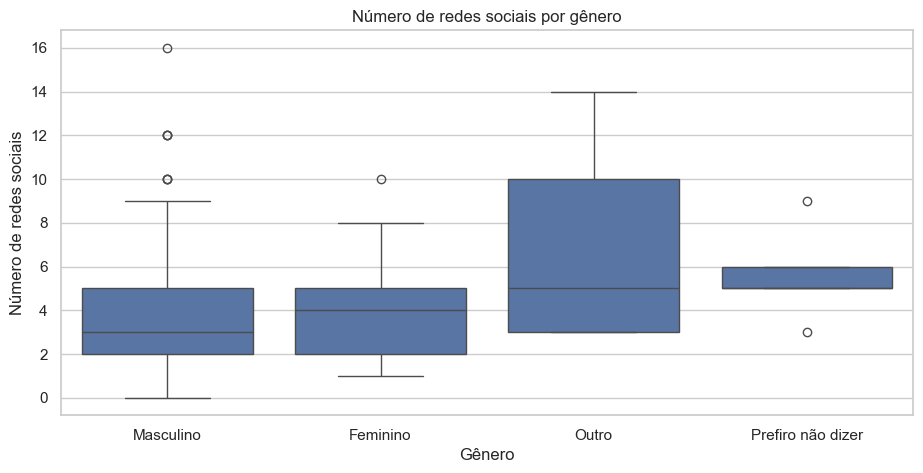

In [37]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x="Gênero", y="Num_redes_sociais", ax=ax)
ax.set_title("Número de redes sociais por gênero")
ax.set_xlabel("Gênero")
ax.set_ylabel("Número de redes sociais")
plt.xticks(rotation=0)
plt.show()

### Comentário para o relatório
Sugestão de redação:

> A variável **Número de redes sociais** é quantitativa discreta, pois representa uma contagem.  
> Em média, os participantes utilizam **4.02** redes sociais, com mediana igual a **3.00**.  
> A comparação por gênero sugere **média ligeiramente maior no grupo Feminino (4.23) do que no Masculino (3.82), enquanto os grupos "Outro" (7.00) e "Prefiro não dizer" (5.60) apresentam médias mais altas, mas com poucos participantes**.


# 7. Comparativo consolidado por gênero

Esta seção reúne as principais variáveis quantitativas em uma única tabela para facilitar a interpretação.

In [38]:
comparativo_genero = (
    df.groupby("Gênero")[["Altura", "Peso", "Num_redes_sociais"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

comparativo_genero

Altura                                  Peso                \
                   count    mean median    std  min  max count   mean median   
Gênero                                                                         
Feminino              31  164.39  164.0   8.09  150  185    31  61.82  59.00   
Masculino            154  175.91  175.0   6.92  160  196   154  74.68  72.15   
Outro                  5  166.40  165.0  10.21  157  182     5  65.00  52.00   
Prefiro não dizer      5  167.20  165.0   5.26  162  175     5  70.00  74.00   

                                      Num_redes_sociais                     \
                     std   min    max             count  mean median   std   
Gênero                                                                       
Feminino           16.02  37.0  120.0                31  4.23    4.0  2.31   
Masculino          14.49  44.0  111.0               154  3.82    3.0  2.53   
Outro              19.80  50.0   90.0                 5  7.00    5.0  4.85   
Prefiro não dizer   9.92  56.0   81.0                 5  5.60    5.0  2.19   

                           
                  min max  
Gênero                     
Feminino            1  10  
Masculino           0  16  
Outro               3  14  
Prefiro não dizer   3   9

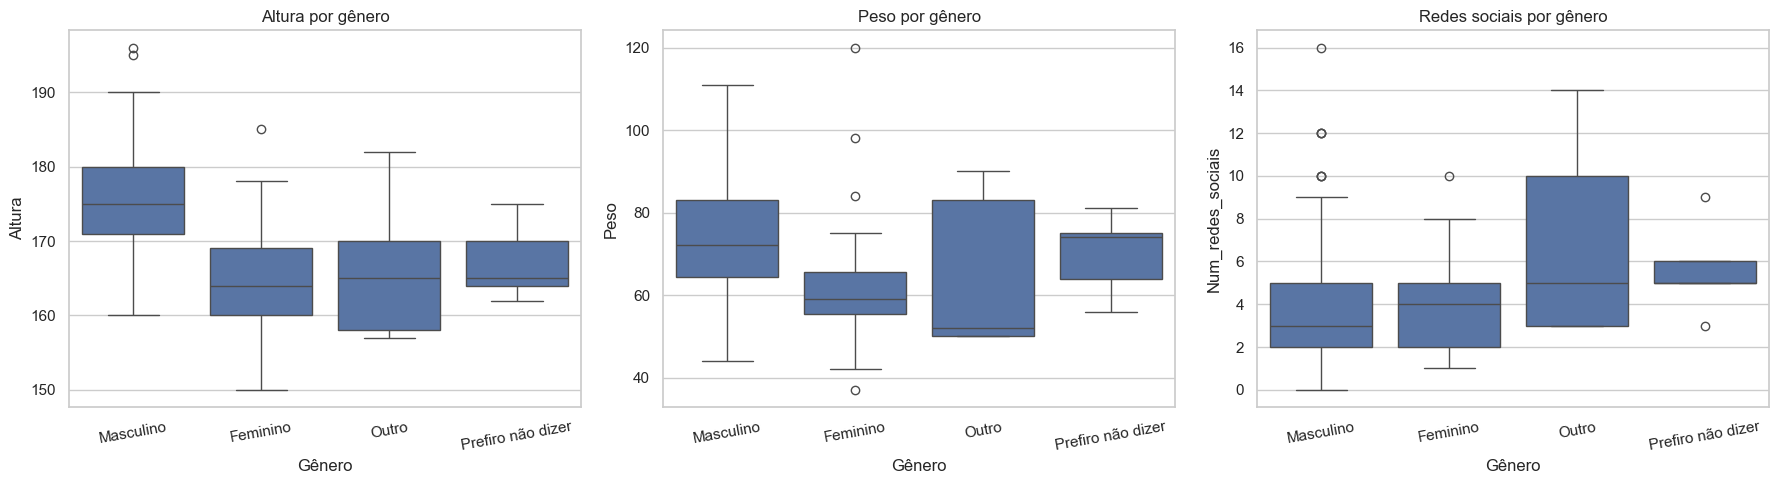

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="Gênero", y="Altura", ax=axes[0])
axes[0].set_title("Altura por gênero")
axes[0].tick_params(axis="x", rotation=10)

sns.boxplot(data=df, x="Gênero", y="Peso", ax=axes[1])
axes[1].set_title("Peso por gênero")
axes[1].tick_params(axis="x", rotation=10)

sns.boxplot(data=df, x="Gênero", y="Num_redes_sociais", ax=axes[2])
axes[2].set_title("Redes sociais por gênero")
axes[2].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()

# 8. Encaminhamento para a próxima parte do trabalho: o relatório

A partir deste notebook, o relatório pode ser estruturado assim:

## 8.1 Introdução
Explique:
- o tema do trabalho;
- por que comparar variáveis por gênero pode ser estatisticamente interessante;
- quais variáveis foram escolhidas.

## 8.2 Metodologia
Descreva:
- a fonte dos dados;
- o tamanho da amostra;
- a classificação das variáveis;
- quais medidas descritivas foram usadas;
- quais gráficos foram utilizados.

## 8.3 Resultados descritivos
Separe por subtópicos:
- distribuição de gênero;
- descrição de altura;
- descrição de peso;
- opinião sobre degradação ambiental;
- opinião sobre regulação de fake news;
- número de redes sociais.

## 8.4 Comparação entre gêneros
Aqui você pode discutir:
- diferenças de média e mediana;
- diferenças de dispersão;
- diferenças visuais observadas nos boxplots;
- diferenças nas distribuições das respostas qualitativas.

## 8.5 Conclusão
Retome:
- os principais achados;
- quais variáveis mostraram diferenças mais visíveis;
- limitações da análise descritiva.

> Observação importante: nesta parte do trabalho, o foco é **descrever** e **comparar visualmente**.  
> Testes inferenciais, se forem exigidos depois, podem aparecer em outra etapa.

## Modelo curto de parágrafo para adaptar no relatório

> Foram analisadas seis variáveis relacionadas ao tema “diferenças estatísticas entre gêneros”: gênero, altura, peso, opinião sobre degradação ambiental, opinião sobre regulação de fake news e número de redes sociais.  
> As variáveis altura e peso foram tratadas como quantitativas contínuas; o número de redes sociais, como quantitativa discreta; gênero e regulação de fake news, como qualitativas nominais; e opinião sobre degradação ambiental, como qualitativa ordinal.  
> A análise descritiva foi realizada por meio de tabelas de frequência, medidas de tendência central, medidas de dispersão e gráficos, permitindo uma visão geral do comportamento das variáveis na amostra e de sua distribuição entre os diferentes grupos de gênero.

## Observação final

Antes de entregar:
1. execute **Run All**;
2. salve o notebook;
3. confira se os gráficos e tabelas aparecem corretamente;
4. exporte para HTML ou PDF, se desejar anexar uma versão estática.